## Xray Lung Classifier 

---
### Project flow  

1) Importing the libraries and Loading the Images

2) Exploring the Images and transforming the Images

3) Creating the model Architecture

4) Training the Data

5) Evaluate the Model 

---
### Importing the libraries and Loading the Images

In [3]:
import os
import numpy as np
import matplotlib.image as mpimg
%matplotlib inline
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from IPython.display import display
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import StepLR
from torchsummary import summary
from tqdm import tqdm


In [5]:
# data path
data_path = 'C:\\Users\\ASUS\\OneDrive\\Desktop\\lung_disease_digonosis\\Data'

---
### Exploring the Images and transforming the Images

In [10]:
# Defining the class name 
class_name = ['NORMAL','PNEUMONIA']

# creating a function to get the list of files
def get_list_of_files(dir_name):
    '''
    input - The input directory location
    output - Returns the list the files in the directory
    '''
    file_list = os.listdir(dir_name)
    return file_list

# passing the data_path and extract the train and test path
file_list_normal_train = get_list_of_files(data_path+'/train/'+class_name[0])
file_list_normal_test = get_list_of_files(data_path+'/test/'+class_name[0])
file_list_pneumonia_train = get_list_of_files(data_path+'/train/'+class_name[1])
file_list_pneumonia_test = get_list_of_files(data_path+'/test/'+class_name[1])

In [11]:
print(f"Number of train samples in Normal category {len(file_list_normal_train)}")
print(f"Number of train samples in Pneumonia category {len(file_list_pneumonia_train)}")
print(f"Number of test samples in Normal category {len(file_list_normal_test)}")
print(f"Number of test samples in Pneumonia category {len(file_list_pneumonia_test)}")

Number of train samples in Normal category 1266
Number of train samples in Pneumonia category 3418
Number of test samples in Normal category 317
Number of test samples in Pneumonia category 855


---
### Exploring the images 

- Let's print the Normal and Pneumonia images from Training folder 

(1407, 1801, 3)


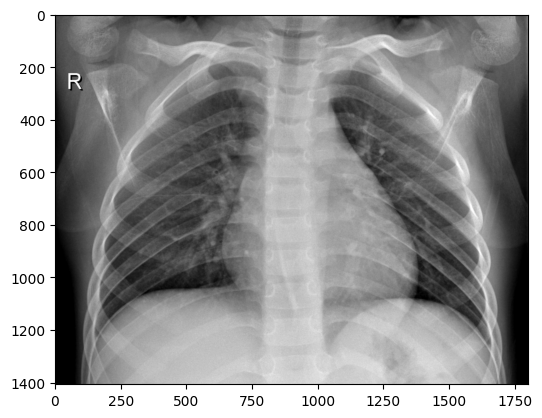

In [12]:
rand_img_no = np.random.randint(0, len(file_list_normal_train))
img = data_path+'/train/NORMAL/'+file_list_normal_train[rand_img_no]
print(plt.imread(img).shape)
img = mpimg.imread(img)
img_plot = plt.imshow(img)
plt.show()

(768, 1096, 3)


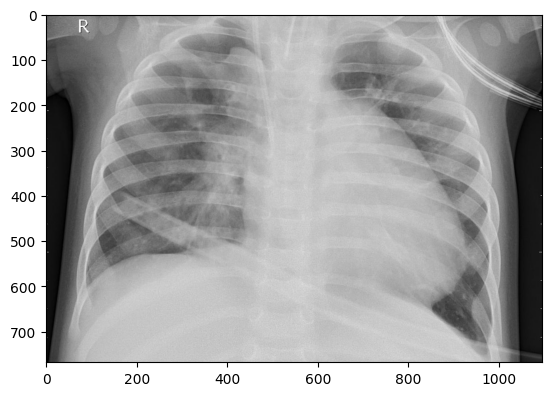

In [13]:
img = data_path + '/train/PNEUMONIA/'+ file_list_pneumonia_train[np.random.randint(0,len(file_list_pneumonia_train))]
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.show()

### Insights 

- If we run the above cell mutiple times we can see that the images are of different shapes for the 'NORMAL' and 'PNEUMONIA' images in the **train** folder.

(2059, 2040, 3)


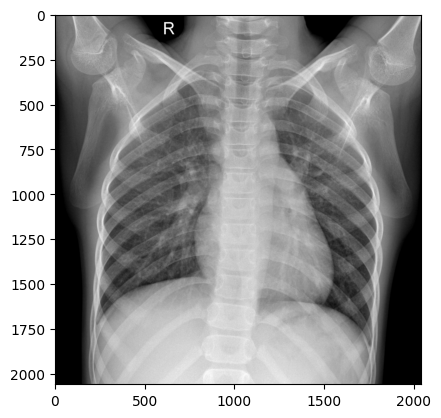

In [15]:
rand_img_no = np.random.randint(0,len(file_list_normal_test))
img = data_path + '/test/NORMAL/'+ file_list_normal_test[rand_img_no]
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.show()

(832, 1016, 3)


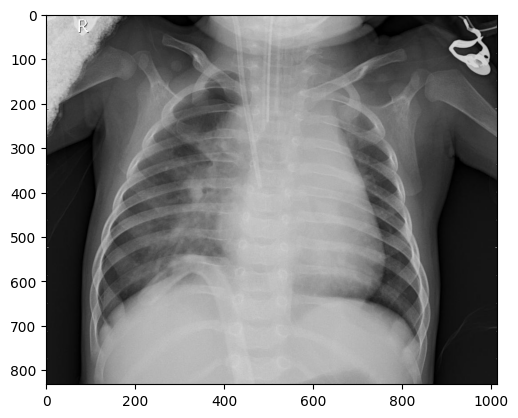

In [16]:
img = data_path + '/test/PNEUMONIA/'+ file_list_pneumonia_test[np.random.randint(0,len(file_list_pneumonia_test))]
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.show()

### Insights 

- If we run the above cell mutiple times we can see that the images are of different shapes for the 'NORMAL' and 'PNEUMONIA' images in the **test** folder.

### Transforming the Images 

- Now that we have seen the sample of the images let's transform the data now 
- We need to perform transformation on both train and test images 
- For Training data we need to perform the data augmentation also.
- Data Augmentation is done to create synthetic data.

In **Transformation** we are doing Resize,CenterCrop,ColorJitter,RandomHorizontalFlip,RandomRotation,ToTensor and Normalize.

- Resize:- Resize the input image to the given size.
- CenterCrop:- Crops the given image at the center.
- ColorJitter:- Randomly change the brightness, contrast, saturation and hue of an image.
- RandomHorizontalFlip:- Horizontally flip the given image randomly with a given probability.
- RandomRotation:- Rotate the image by angle.
- ToTensor:- Convert numpy.ndarray to tensor.
- Normalize:- Normalize a float tensor image with mean and standard deviation.

In [ ]:
# Data Transformation
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    # Data Agumentation
    transforms.CenterCrop(224),
    transforms.ColorJitter(brightness=0.10, contrast=0.1, saturation=0.10, hue=0.1),
    transforms.RandomHorizontalFlip(), # Randomly flips the image left-to-right.
    transforms.RandomRotation(10), # Randomly rotates the image.(between -10 to +10 degree)
    # preprocess
    transforms.ToTensor(), # convert it into pytorch tensor
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224), # CenterCrop crops the center portion of an image to a specified size.
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

### Creating Data Loader

- For our usecase will be using the default data loader for Pytorch.
- We will be creating 2 data loaders one for the training data and other for the test data.
- batch size is a hyperparameter which we can tweak according to our need and system configuration.
- We can provide Image shuffling True for training data and False for test data.
- Pin memory is used to transfer the loaded dataset from CPU to GPU. 

In [20]:
train_data = datasets.ImageFolder(
    os.path.join(data_path, 'train'),
    transform=train_transform
)

test_data = datasets.ImageFolder(
    os.path.join(data_path, 'test'),
    transform=test_transform
)

# data loader
train_loader = DataLoader(
    dataset=train_data,
    batch_size=16,
    shuffle=True,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_data,
    batch_size=16,
    shuffle=False,
    pin_memory=True
)

name_classes = train_data.classes
print(f"Class Name: {name_classes}")

print(f"Number of images in train data: {len(train_data)}")       
print(f"Number of images in test data: {len(test_data)}")

Class Name: ['NORMAL', 'PNEUMONIA']
Number of images in train data: 4684
Number of images in test data: 1172


---
### Creating the model Architecture

- First Layer is the **input layer** consisting of 3 input channels and output channels with kernel_size of 3X3, padding=0 and bias=True. The activation function we are using is ReLU and performing batch normalization.
- Then we are performing max pooling to extract the important features out of the image.
- Similarly we are passing our model through 9 convolutional layers.
- Finally we are passing out passing our model through a output layer in which we are getting binary classification.


In [ ]:
# custom cnn
class Net(nn.Module):
    